Load data and model

In [1]:
import pandas as pd
import pickle
import sys
sys.path.append("..")


df = pd.read_pickle("../data/features_v3.pkl")

with open("models/model_v3.pkl", "rb") as f:
    model = pickle.load(f)

Prepare the data

In [2]:
from python_editor.data_processing import split_by_developer, get_vectorized_features_and_label

train, test = split_by_developer(df, test_size=0.3, random_state=0)

In [3]:
from python_editor.feature_generation_v2 import TRANSFORMED_FEATURES, LOG_FEATURES, generate_transformed_features

X_test, y_test = get_vectorized_features_and_label(test, TRANSFORMED_FEATURES)

Get predictions

In [4]:
y_pred = model.predict(X_test)

The asymmetry in residuals is back (from -8 to 6)

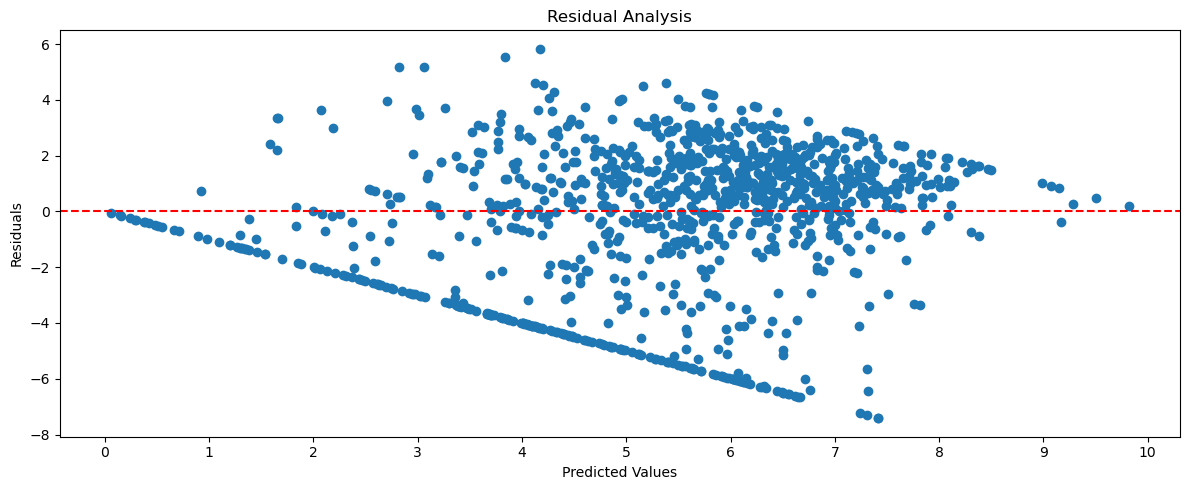

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

plt.scatter(y_pred, y_test-y_pred)
plt.axhline(y=0, color="r", linestyle="--")
plt.xticks(range(11))
plt.title("Residual Analysis")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [6]:
test.loc[:, "error"] = y_test - y_pred

/tmp/ipykernel_77655/4180407341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, "error"] = y_test - y_pred


We examine top performing, most over estimated and most under estimated examples. We see that the higher number characters and degree of complexity result in higher score

In [7]:
import numpy as np
from python_editor.model_evaluation import get_top_k

test_og = test.copy()
test_og.loc[:, LOG_FEATURES] = np.expm1(test_og[LOG_FEATURES])

top_performing, most_over_estimated, most_under_estimated = get_top_k(test_og, "error", 3)

to_display = TRANSFORMED_FEATURES + ["pylint_score", "error"]
pd.set_option("display.max_columns", None)

Top performing examples have:

1- Average pylint score

2- No docstring

In [8]:
top_performing[to_display]

,characters,code_compactness,line_length_std,cyclomatic_complexity,long_line,bad_name,comment_ratio,has_docstring,variable_density,func_density,too_many_args,class_density,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
969,780.0,0.800000,41.936708,1.0,1.0,0.0,0.100000,0.0,0.100000,0.000000,0.0,0.050000,0.000000,0.0,1.0,2.00000,0.002273
976,14936.0,0.756646,17.214405,4.0,0.0,1.0,0.040541,0.0,0.086486,0.089189,0.0,0.024324,3.666667,0.0,0.0,7.04918,0.007621
2427,6473.0,0.744076,26.914341,1.0,1.0,0.0,0.643312,0.0,0.165605,0.000000,0.0,0.000000,0.000000,0.0,0.0,4.83871,-0.007635


Overestimated examples have:

1- Average to high number of characters

2- Average to high cyclomatic complexity

In [11]:
most_over_estimated[to_display]

,characters,code_compactness,line_length_std,cyclomatic_complexity,long_line,bad_name,comment_ratio,has_docstring,variable_density,func_density,too_many_args,class_density,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
2970,13677.0,0.770833,21.027213,6.0,0.0,1.0,0.070946,1.0,0.094595,0.037162,1.0,0.003378,11.0,1.0,0.0,0.0,-7.416932
1692,1210.0,0.707317,17.605061,2.0,0.0,1.0,0.068966,1.0,0.137931,0.068966,0.0,0.034483,2.0,1.0,0.0,0.0,-7.416406
2827,8553.0,0.874372,22.918644,2.0,0.0,1.0,0.022989,1.0,0.040230,0.022989,0.0,0.005747,4.0,1.0,0.0,0.0,-7.307318


Underestimated examples have: 

1- Average to low number of characters

2- No functions/classes

In [10]:
most_under_estimated[to_display]

,characters,code_compactness,line_length_std,cyclomatic_complexity,long_line,bad_name,comment_ratio,has_docstring,variable_density,func_density,too_many_args,class_density,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
1033,1022.0,0.741935,25.702162,1.0,0.0,0.0,0.565217,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,10.000,5.830564
364,1298.0,1.000000,15.886172,1.0,0.0,0.0,0.032258,0.0,0.032258,0.0,0.0,0.0,0.0,0.0,0.0,9.375,5.533807
1553,1369.0,0.979167,23.185301,1.0,1.0,0.0,0.000000,0.0,0.021277,0.0,0.0,0.0,0.0,0.0,0.0,8.000,5.176286


Feature importance shows that the model relies on continous features more than discrete ones

In [12]:
from python_editor.model_evaluation import get_feature_importance


importance_df = get_feature_importance(model, TRANSFORMED_FEATURES)
importance_df

,feature,importance
2,line_length_std,0.155299
0,characters,0.140255
8,variable_density,0.110910
1,code_compactness,0.110396
6,comment_ratio,0.101223
9,func_density,0.076983
11,class_density,0.071195
13,func_class_docstring_ratio,0.049901
3,cyclomatic_complexity,0.049130
12,avg_class_methods,0.032752


In [13]:
X_train, y_train = get_vectorized_features_and_label(train, TRANSFORMED_FEATURES)

100%|===================| 1055/1060 [02:37<00:00]        

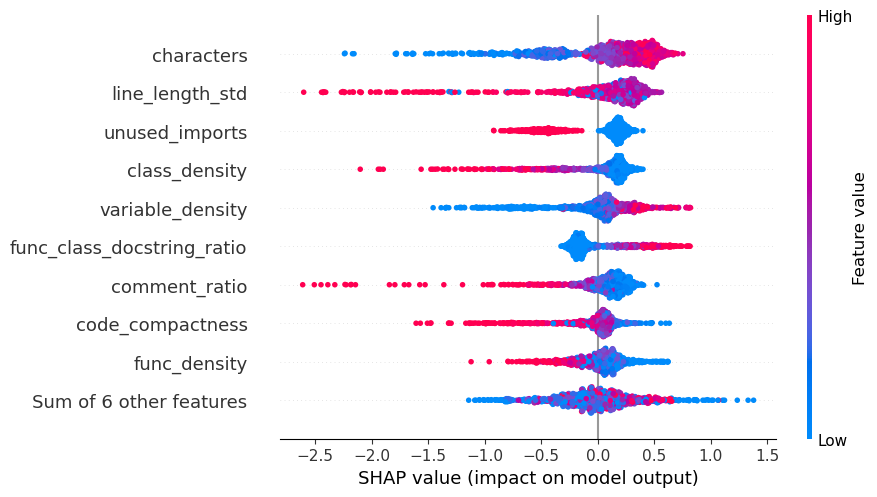

In [14]:
import shap
from python_editor.model_evaluation import get_shap_df
shap.initjs()

shap_values = get_shap_df(model, TRANSFORMED_FEATURES, X_train, X_test)
shap.plots.beeswarm(shap_values)

Our model is now 12x faster than Pylint. Although we lost some performance it was worth it.

In [15]:
from python_editor.data_processing import get_pylint_text
from python_editor.model_evaluation import compare_time

compare_time(get_pylint_text, generate_transformed_features, model, test["text"][0:100], embedding_dim=0)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:12<00:00,  1.32s/it]


{'model_time': 0.09607289314270019, 'pylint_time': 1.2238623690605164}